In [24]:
import torch
import json
import numpy as np
import torch.nn as nn

DATA_DIR = "/kaggle/input/datasets/f0rzah/saved-model/saved_model"

## Загрузка гиперпараметров и словарей

In [25]:
with open(f"{DATA_DIR}/hyperparams.json", "r") as f:
    hyperparams = json.load(f)

with open(f"{DATA_DIR}/vocab.json", "r") as f:
    vocab_data = json.load(f)
    item2idx = vocab_data["item2idx"]
    idx2item = {int(k): v for k, v in vocab_data["idx2item"].items()}

## Минимальная версия модели для получения эмбеддингов

In [26]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class SASRec(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, max_seq_len, dropout=0.2):
        super().__init__()
        self.item_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=max_seq_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ln_f = nn.LayerNorm(embed_dim)

## Инициализация


In [27]:
model = SASRec(
    vocab_size=hyperparams["vocab_size"],
    embed_dim=hyperparams["embed_dim"],
    num_heads=hyperparams["num_heads"],
    num_layers=hyperparams["num_layers"],
    max_seq_len=hyperparams["max_seq_len"],
    dropout=hyperparams["dropout"]
)

model.load_state_dict(torch.load(f"{DATA_DIR}/model_weights.pth", map_location="cpu"))
model.eval()
print(f"✅ Модель загружена: {hyperparams['best_model']}")

✅ Модель загружена: TRON (Reg)


## Подготовка данных для кластеризации

In [28]:
special_tokens = {'[PAD]', '[MASK]'}
all_items = [item for item in item2idx.keys() if item not in special_tokens]
item_indices = [item2idx[item] for item in all_items]

print(f" Всего вопросов для кластеризации: {len(all_items)}")

 Всего вопросов для кластеризации: 12079


In [29]:
with torch.no_grad():
    indices_tensor = torch.tensor(item_indices, dtype=torch.long)
    embeddings = model.item_embedding(indices_tensor).numpy()

print(f"✅ Эмбеддинги получены: {embeddings.shape}")

✅ Эмбеддинги получены: (12079, 64)


## Сам процесс кластеризации

In [30]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

k_range = range(2, 21)  
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(embeddings)
    
    inertias.append(kmeans.inertia_)
    score = silhouette_score(embeddings, kmeans.labels_)
    silhouette_scores.append(score)
    
    print(f"   k={k:2d}: Inertia={kmeans.inertia_:,.0f}, Silhouette={score:.3f}")

print("Расчеты завершены!")

# Выбор лучшего k (по максимальному Silhouette Score)
best_k_idx = np.argmax(silhouette_scores)
best_k = list(k_range)[best_k_idx]
best_score = silhouette_scores[best_k_idx]

print(f"\nОПТИМАЛЬНОЕ КОЛИЧЕСТВО ТЕМ: {best_k}")
print(f"   Silhouette Score: {best_score:.3f}")
print(f"   Inertia: {inertias[best_k_idx]:,.0f}")

   k= 2: Inertia=558, Silhouette=0.228
   k= 3: Inertia=477, Silhouette=0.238
   k= 4: Inertia=430, Silhouette=0.252
   k= 5: Inertia=401, Silhouette=0.254
   k= 6: Inertia=383, Silhouette=0.249
   k= 7: Inertia=370, Silhouette=0.249
   k= 8: Inertia=358, Silhouette=0.139
   k= 9: Inertia=347, Silhouette=0.143
   k=10: Inertia=336, Silhouette=0.144
   k=11: Inertia=328, Silhouette=0.142
   k=12: Inertia=322, Silhouette=0.142
   k=13: Inertia=316, Silhouette=0.144
   k=14: Inertia=311, Silhouette=0.144
   k=15: Inertia=307, Silhouette=0.144
   k=16: Inertia=302, Silhouette=0.142
   k=17: Inertia=298, Silhouette=0.143
   k=18: Inertia=294, Silhouette=0.140
   k=19: Inertia=291, Silhouette=0.139
   k=20: Inertia=289, Silhouette=0.131
Расчеты завершены!

ОПТИМАЛЬНОЕ КОЛИЧЕСТВО ТЕМ: 5
   Silhouette Score: 0.254
   Inertia: 401


## Визуализация

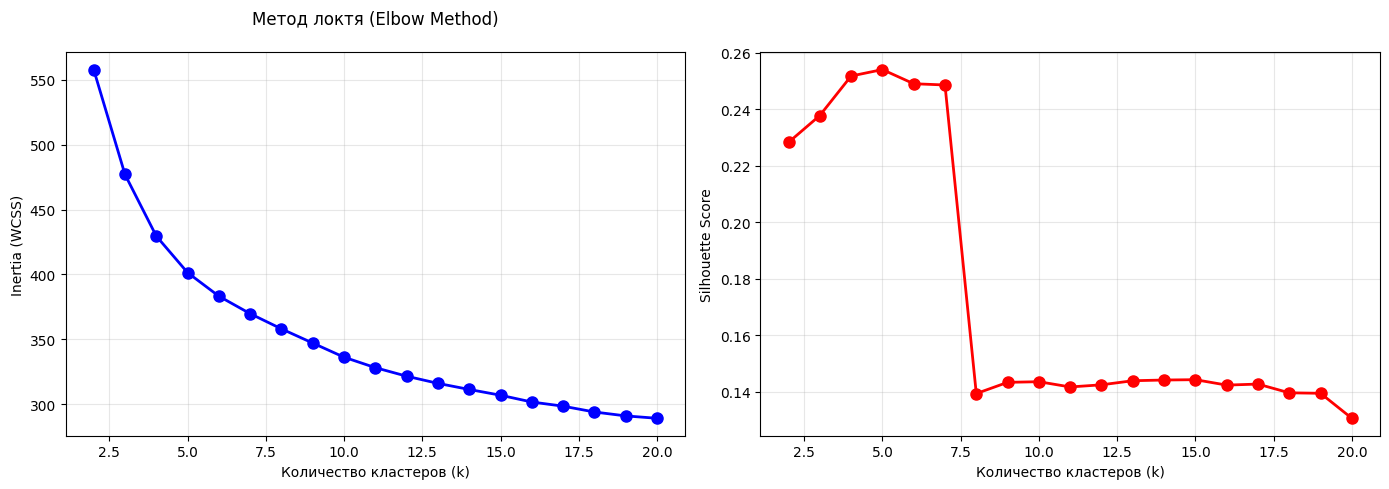

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Inertia (Elbow)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Метод локтя (Elbow Method)\n')
axes[0].grid(True, alpha=0.3)

# График 2: Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Применим лучшее разбиение

In [32]:
import json

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(embeddings)

# Формируем словарь: {номер_темы: [список_вопросов]}
cluster_dict = {}
for i, item in enumerate(all_items):
    cluster_id = int(clusters[i])
    if cluster_id not in cluster_dict:
        cluster_dict[cluster_id] = []
    cluster_dict[cluster_id].append(item)

# Сортируем вопросы внутри каждой темы
for cid in cluster_dict:
    cluster_dict[cid].sort()

In [33]:
cluster_info = {
    "optimal_k": int(best_k),
    "silhouette_score": float(best_score),
    "inertia": float(inertias[best_k_idx]),
    "method": "elbow_and_silhouette",
    "clusters": {str(k): v for k, v in cluster_dict.items()}
}

# Сохраняем
with open("cluster_info.json", "w") as f:
    json.dump(cluster_info, f, indent=2)

print(f"✅ Файл cluster_info.json сохранен!")

print(f"\n📊 Распределение {len(all_items)} вопросов по {best_k} темам:")
print("="*60)

total_items = 0
for cid in sorted(cluster_dict.keys()):
    items = cluster_dict[cid]
    total_items += len(items)
    pct = len(items) / len(all_items) * 100
    examples = ", ".join(items[:5])
    print(f"Тема {cid}: {len(items):>4} вопросов ({pct:>5.1f}%)")
    print(f"         Примеры: {examples}...")

print("="*60)
print(f"ВСЕГО: {total_items} вопросов")

✅ Файл cluster_info.json сохранен!

📊 Распределение 12079 вопросов по 5 темам:
Тема 0: 1354 вопросов ( 11.2%)
         Примеры: q1, q100, q1000, q1001, q10012...
Тема 1: 1468 вопросов ( 12.2%)
         Примеры: q10001, q10003, q10006, q10010, q10016...
Тема 2: 2415 вопросов ( 20.0%)
         Примеры: q10011, q10032, q10036, q10045, q10047...
Тема 3: 4101 вопросов ( 34.0%)
         Примеры: q10013, q10015, q10017, q10019, q1002...
Тема 4: 2741 вопросов ( 22.7%)
         Примеры: q10, q10000, q10002, q10004, q10005...
ВСЕГО: 12079 вопросов


In [34]:
hyperparams["optimal_clusters"] = int(best_k)
hyperparams["cluster_silhouette_score"] = float(best_score)

with open("hyperparams_updated.json", "w") as f:
    json.dump(hyperparams, f, indent=2)

print(f"\n✅ hyperparams_updated.json сохранен!")
print(f"   (содержит информацию о {best_k} темах)")


✅ hyperparams_updated.json сохранен!
   (содержит информацию о 5 темах)
